In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
import sys
sys.path.append("/home/563/as8561/side_projects/extreme_el_nino_2026/")

In [4]:
from functions import preproc_funcs as funcs

In [5]:
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/historical/r10i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/piControl/r1i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/ScenarioMIP/**/**/ssp585/r10i1p1f1/Amon/tas/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/abrupt-4xCO2/r1i1p1f1/Amon/ts/gn/**/*.nc')

In [6]:
import gzip
from pathlib import Path


In [7]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # --- type sizes: consistent hierarchy (title > labels > ticks/legend) ---
    "font.size":        9,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.titlesize": 12,

    # --- lines & ticks: slightly heavier so they hold up next to bigger text ---
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.2,
    "patch.linewidth":   0.8,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size":  3.0, "ytick.major.size":  3.0,
    "xtick.minor.width": 0.6, "ytick.minor.width": 0.6,
    "xtick.minor.size":  1.8, "ytick.minor.size":  1.8,
    "xtick.direction": "out", "ytick.direction": "out",

    # --- spines & legend ---
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 6, "axes.labelpad": 4,
    "legend.frameon": False,
    "legend.handletextpad": 0.4,
    "legend.labelspacing": 0.35,

    # --- output ---
    "figure.dpi": 150, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # editable text in Illustrator
})

MM = 1/25.4
SINGLE_COL = 89  * MM
DOUBLE_COL = 183 * MM

In [8]:
def set_scale(mode="draft"):
    s = {"draft": 1.0, "submit": 0.85}[mode]      # 0.7 → ~7pt base, 7.7pt title
    mpl.rcParams.update({
        "font.size": 9*s, "axes.titlesize": 11*s, "axes.labelsize": 10*s,
        "xtick.labelsize": 9*s, "ytick.labelsize": 9*s, "legend.fontsize": 9*s,
    })
set_scale("submit")

##  model evaluation

In [9]:
import glob, os
from collections import defaultdict

VARIANT = "r1i1p1f1"
GRIDS   = ["gn", "gr", "gr1"]

def parse(path):
    p = path.split("/"); i = p.index("historical"); j = p.index("ts", i)
    return p[i-1], p[j+1], p[j+2]                 # model, grid, version

tree = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for g in GRIDS:
    for f in glob.glob(f"/g/data/*/*/CMIP6/CMIP/*/*/historical/{VARIANT}/Amon/ts/{g}/*/*.nc"):
        m, grid, ver = parse(f)
        tree[m][grid][ver].append(f)

hist = {}
for m, grids in tree.items():
    grid = next(g for g in GRIDS if g in grids)   # prefer gn > gr > gr1
    ver  = sorted(grids[grid])[-1]                # latest version
    hist[m] = dict(grid=grid, version=ver, files=sorted(grids[grid][ver]))

print(f"{len(hist)} models\n")
for m in sorted(hist):
    print(f"  {m:28s} {hist[m]['grid']:4s} {len(hist[m]['files'])} files")

53 models

  ACCESS-CM2                   gn   1 files
  ACCESS-ESM1-5                gn   1 files
  AWI-CM-1-1-MR                gn   165 files
  AWI-ESM-1-1-LR               gn   165 files
  BCC-CSM2-MR                  gn   1 files
  BCC-ESM1                     gn   1 files
  CAMS-CSM1-0                  gn   1 files
  CAS-ESM2-0                   gn   1 files
  CESM2                        gn   1 files
  CESM2-FV2                    gn   4 files
  CESM2-WACCM                  gn   1 files
  CESM2-WACCM-FV2              gn   4 files
  CIESM                        gr   1 files
  CMCC-CM2-HR4                 gn   1 files
  CMCC-CM2-SR5                 gn   1 files
  CMCC-ESM2                    gn   1 files
  CanESM5                      gn   1 files
  E3SM-1-0                     gr   7 files
  E3SM-1-1                     gr   17 files
  E3SM-1-1-ECA                 gr   17 files
  EC-Earth3                    gr   165 files
  EC-Earth3-CC                 gr   165 files
  EC-Earth3

In [10]:
import regionmask, numpy as np, pandas as pd, xarray as xr
from scipy.stats import skew
from tqdm.auto import tqdm

try:    _LAND = regionmask.defined_regions.natural_earth_v5_0_0.land_110
except AttributeError: _LAND = regionmask.defined_regions.natural_earth.land_110

def load_ts(m):
    ds = xr.open_mfdataset(hist[m]["files"], combine="by_coords",
                           use_cftime=True, chunks={"time": 120})
    da = ds["ts"]
    ren = {}
    for c in list(da.coords):
        cl = c.lower()
        if cl in ("latitude", "lat", "y"):  ren[c] = "lat"
        elif cl in ("longitude", "lon", "x"): ren[c] = "lon"
    da = da.rename(ren).assign_coords()          # ensure names
    da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")
    return da.sel(time=slice("1900", "2000"))

def rel_n34(da, ocean):
    n34  = da.sel(lat=slice(-5, 5), lon=slice(190, 240))
    n34  = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat", "lon"))
    band = da.sel(lat=slice(-20, 20)); ob = ocean.sel(lat=slice(-20, 20))
    trp  = band.where(ob).weighted(np.cos(np.deg2rad(band.lat))).mean(("lat", "lon"))
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    return (n34a - trpa).rolling(time=3, center=True).mean()

model_skew = {}
for m in tqdm(sorted(hist)):
    try:
        da    = load_ts(m)
        ocean = np.isnan(_LAND.mask(da.lon, da.lat))          # True over ocean
        rel   = rel_n34(da, ocean).compute().dropna("time")   # only the 1-D series is read
        model_skew[m] = float(skew(rel.values))
    except Exception as e:
        tqdm.write(f"  {m:24s} SKIP {type(e).__name__}: {str(e)[:60]}")

sk = pd.Series(model_skew).sort_values()
print(f"\n{len(sk)} models with skewness:\n")
print(sk.round(3).to_string())

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


  0%|          | 0/53 [00:00<?, ?it/s]

  ICON-ESM-LR              SKIP KeyError: "no index found for coordinate 'lat'"

52 models with skewness:

ACCESS-ESM1-5       -0.504
BCC-CSM2-MR         -0.502
IITM-ESM            -0.443
FGOALS-g3           -0.441
GISS-E2-1-G-CC      -0.320
ACCESS-CM2          -0.311
NorCPM1             -0.307
CAMS-CSM1-0         -0.251
BCC-ESM1            -0.211
MPI-ESM1-2-HR       -0.197
FGOALS-f3-L         -0.187
KIOST-ESM           -0.172
IPSL-CM6A-LR-INCA   -0.165
AWI-ESM-1-1-LR      -0.164
GISS-E2-1-G         -0.163
IPSL-CM5A2-INCA     -0.127
NorESM2-LM          -0.095
INM-CM5-0           -0.077
NorESM2-MM          -0.067
EC-Earth3-CC        -0.064
CAS-ESM2-0          -0.041
GFDL-ESM4           -0.040
CESM2               -0.005
KACE-1-0-G           0.017
E3SM-1-1             0.030
AWI-CM-1-1-MR        0.052
CanESM5              0.061
CESM2-FV2            0.077
GFDL-CM4             0.104
GISS-E2-1-H          0.151
INM-CM4-8            0.171
E3SM-1-0             0.173
IPSL-CM6A-LR         0.182
CE

In [11]:
import gzip
from pathlib import Path

obs_dir  = Path("/g/data/if69/as8561/data/obs_SST_products")
obs_files = {"COBE": "COBE_sst.mon.mean.nc", "DCSST": "DCSST-I_mean_1x1.nc",
             "HadISST": "HadISST_sst.nc.gz", "ERSSTv5": "ersst_v5.nc"}

def open_obs(n):
    p = obs_dir / obs_files[n]
    if str(p).endswith(".gz"):
        with gzip.open(p) as f: return xr.open_dataset(f).load()
    return xr.open_dataset(p)

def std_obs(ds):
    v  = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[v]
    ren = {}
    for c in da.coords:
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        if cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren).squeeze(drop=True)
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    return da.where((da > -5) & (da < 45))

def obs_rel_series(n):                                    # was obs_rel_skew, now returns the series
    da  = std_obs(open_obs(n)).sel(time=slice("1900", "2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    bnd = da.sel(lat=slice(-20,20))
    trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    rel  = (n34a - trpa).rolling(time=3, center=True).mean().dropna("time")
    return rel.values                                     # <- series, not float

obs_ser  = {n: obs_rel_series(n) for n in obs_files}
obs_skew = {n: float(skew(s)) for n, s in obs_ser.items()}
obs_lo, obs_hi = min(obs_skew.values()), max(obs_skew.values())

print("observed relative-Niño3.4 skewness (1900–2000):")
for n, s in obs_skew.items(): print(f"  {n:8s} {s:+.3f}  (n={len(obs_ser[n])} months)")
print(f"\nobserved envelope: {obs_lo:+.3f} to {obs_hi:+.3f}")

observed relative-Niño3.4 skewness (1900–2000):
  COBE     +0.174  (n=1210 months)
  DCSST    +0.390  (n=1210 months)
  HadISST  +0.080  (n=1210 months)
  ERSSTv5  +0.319  (n=1210 months)

observed envelope: +0.080 to +0.390


In [12]:
def block_bootstrap_skew(x, n_boot=10000, block=36, seed=0):
    """Moving-block bootstrap; block in months (36 = 3 yr, preserves ENSO events)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x); n = len(x)
    nb = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=(n_boot, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n_boot, -1)[:, :n]
    return skew(x[idx], axis=1)

BLOCK, NBOOT = 36, 10000
boot = {n: block_bootstrap_skew(s, NBOOT, BLOCK) for n, s in obs_ser.items()}

print(f"block = {BLOCK} months, {NBOOT} resamples\n")
print(f"{'product':10s} {'point':>7s} {'mean':>7s} {'5th':>7s} {'95th':>7s}")
for n, b in boot.items():
    print(f"  {n:8s} {obs_skew[n]:+7.3f} {b.mean():+7.3f} "
          f"{np.percentile(b,5):+7.3f} {np.percentile(b,95):+7.3f}")


block = 36 months, 10000 resamples

product      point    mean     5th    95th
  COBE      +0.174  +0.226  -0.029  +0.489
  DCSST     +0.390  +0.404  +0.184  +0.632
  HadISST   +0.080  +0.139  -0.160  +0.440
  ERSSTv5   +0.319  +0.330  +0.112  +0.547


In [13]:
# --- consistency across products ---
lo = {n: np.percentile(b, 5) for n, b in boot.items()}
hi = {n: np.percentile(b, 95) for n, b in boot.items()}
clo, chi = max(lo.values()), min(hi.values())
print(f"\nintersection of all four CIs: [{clo:+.3f}, {chi:+.3f}]",
      "\u2192 CONSISTENT" if clo < chi else "\u2192 NOT consistent")
names = list(boot)
for i, a in enumerate(names):
    for b_ in names[i+1:]:
        ov = min(hi[a], hi[b_]) - max(lo[a], lo[b_])
        print(f"  {a:8s} vs {b_:8s} {'overlap' if ov > 0 else 'DISJOINT':>8s} ({ov:+.3f})")


intersection of all four CIs: [+0.184, +0.440] → CONSISTENT
  COBE     vs DCSST     overlap (+0.305)
  COBE     vs HadISST   overlap (+0.469)
  COBE     vs ERSSTv5   overlap (+0.377)
  DCSST    vs HadISST   overlap (+0.256)
  DCSST    vs ERSSTv5   overlap (+0.363)
  HadISST  vs ERSSTv5   overlap (+0.328)


In [14]:
gate = [m for m, s in model_skew.items() if obs_lo <= s <= obs_hi]

In [15]:

# --- block-length sensitivity ---
print("\nblock sensitivity (pooled 5\u201395%):")
for bl in (24, 36, 60):
    p = np.concatenate([block_bootstrap_skew(s, 4000, bl) for s in obs_ser.values()])
    print(f"  block={bl:3d} mo  [{np.percentile(p,5):+.3f}, {np.percentile(p,95):+.3f}]")

# --- pooled envelope + new gate ---
pooled = np.concatenate(list(boot.values()))
GLO, GHI = np.percentile(pooled, [5, 95])
print(f"\npooled envelope (5\u201395%): [{GLO:+.3f}, {GHI:+.3f}]"
      f"   | previous inter-product: [{obs_lo:+.3f}, {obs_hi:+.3f}]")

gate_boot = [m for m, s in model_skew.items() if GLO <= s <= GHI]
print(f"\n{len(gate_boot)} models pass (was {len(gate)}):")
for m in sorted(gate_boot, key=lambda x: model_skew[x]):
    print(f"  {m:22s} {model_skew[m]:+.3f}")
print("\n  newly included:", sorted(set(gate_boot) - set(gate)) or "\u2014")
print("  now excluded  :", sorted(set(gate) - set(gate_boot)) or "\u2014")


block sensitivity (pooled 5–95%):
  block= 24 mo  [-0.063, +0.550]
  block= 36 mo  [-0.043, +0.560]
  block= 60 mo  [-0.044, +0.544]

pooled envelope (5–95%): [-0.045, +0.558]   | previous inter-product: [+0.080, +0.390]

29 models pass (was 15):
  CAS-ESM2-0             -0.041
  GFDL-ESM4              -0.040
  CESM2                  -0.005
  KACE-1-0-G             +0.017
  E3SM-1-1               +0.030
  AWI-CM-1-1-MR          +0.052
  CanESM5                +0.061
  CESM2-FV2              +0.077
  GFDL-CM4               +0.104
  GISS-E2-1-H            +0.151
  INM-CM4-8              +0.171
  E3SM-1-0               +0.173
  IPSL-CM6A-LR           +0.182
  CESM2-WACCM-FV2        +0.187
  CESM2-WACCM            +0.192
  MPI-ESM1-2-LR          +0.192
  E3SM-1-1-ECA           +0.195
  SAM0-UNICON            +0.235
  CMCC-CM2-HR4           +0.246
  MRI-ESM2-0             +0.256
  EC-Earth3-Veg-LR       +0.314
  NESM3                  +0.357
  FIO-ESM-2-0            +0.377
  MIROC6        

In [16]:
BUFFER = 0.00                                   # tolerance ≈ bootstrap noise on the CI edges
GLO, GHI = clo - BUFFER, chi + BUFFER
gate = [m for m, s in model_skew.items() if GLO <= s <= GHI]

print(f"gate: [{clo:+.3f}, {chi:+.3f}] \u00b1{BUFFER}  \u2192  [{GLO:+.3f}, {GHI:+.3f}]"
      f"  \u2192 {len(gate)} models\n")
for m in sorted(gate, key=lambda x: model_skew[x]):
    edge = "  (buffer)" if not (clo <= model_skew[m] <= chi) else ""
    print(f"  {m:22s} {model_skew[m]:+.3f}{edge}")

near = {m: s for m, s in model_skew.items()
        if (GLO-0.05 <= s < GLO) or (GHI < s <= GHI+0.05)}
print("\nstill just outside:", {m: round(s, 3) for m, s in sorted(near.items(), key=lambda kv: kv[1])})


gate: [+0.184, +0.440] ±0.0  →  [+0.184, +0.440]  → 12 models

  CESM2-WACCM-FV2        +0.187
  CESM2-WACCM            +0.192
  MPI-ESM1-2-LR          +0.192
  E3SM-1-1-ECA           +0.195
  SAM0-UNICON            +0.235
  CMCC-CM2-HR4           +0.246
  MRI-ESM2-0             +0.256
  EC-Earth3-Veg-LR       +0.314
  NESM3                  +0.357
  FIO-ESM-2-0            +0.377
  MIROC6                 +0.416
  EC-Earth3              +0.424

still just outside: {'GISS-E2-1-H': 0.151, 'INM-CM4-8': 0.171, 'E3SM-1-0': 0.173, 'IPSL-CM6A-LR': 0.182, 'MPI-ESM-1-2-HAM': 0.445}


In [17]:
# print(f"{len(gate)} models pass the skewness gate [{obs_lo:+.2f}, {obs_hi:+.2f}]:\n")
# for m in sorted(gate, key=lambda x: model_skew[x]):
#     print(f"  {m:22s} {model_skew[m]:+.3f}")
# print("\nrejected — too SYMMETRIC/negative:",
#       ", ".join(sorted((m for m, s in model_skew.items() if s < obs_lo), key=lambda x: model_skew[x])))
# print("\nrejected — too SKEWED:",
#       ", ".join(sorted((m for m, s in model_skew.items() if s > obs_hi), key=lambda x: model_skew[x])))

In [18]:
def discover(activity, experiment, variant="r1i1p1f1", grids=("gn","gr","gr1")):
    found = {}
    for g in grids:
        pat = f"/g/data/*/replicas/CMIP6/{activity}/*/*/{experiment}/{variant}/Amon/ts/{g}/*/*.nc"
        for f in glob.glob(pat):
            p = f.split("/"); i = p.index(experiment); j = p.index("ts", i)
            found.setdefault(p[i-1], {}).setdefault(p[j+1], {}).setdefault(p[j+2], []).append(f)
    out = {}
    for m, gr in found.items():
        grid = next(gg for gg in grids if gg in gr)
        ver  = sorted(gr[grid])[-1]
        out[m] = dict(grid=grid, version=ver, files=sorted(gr[grid][ver]))
    return out

exps  = {"piControl": ("CMIP","piControl"), "abrupt-4xCO2": ("CMIP","abrupt-4xCO2"),
         "ssp245": ("ScenarioMIP","ssp245"), "ssp585": ("ScenarioMIP","ssp585")}
avail = {name: discover(act, exp) for name, (act, exp) in exps.items()}

tab = pd.DataFrame({name: {m: (m in a) for m in gate} for name, a in avail.items()})
tab.insert(0, "historical", True)
print("experiment availability (gated models, r1i1p1f1):\n")
print(tab.loc[sorted(gate)].replace({True: "\u2713", False: "\u2014"}).to_string())
print("\ncomplete (all 4 forced exps):",
      [m for m in gate if all(m in avail[e] for e in exps)])



experiment availability (gated models, r1i1p1f1):

                 historical piControl abrupt-4xCO2 ssp245 ssp585
CESM2-WACCM               ✓         ✓            ✓      ✓      ✓
CESM2-WACCM-FV2           ✓         ✓            ✓      —      —
CMCC-CM2-HR4              ✓         —            ✓      —      —
E3SM-1-1-ECA              ✓         ✓            —      —      —
EC-Earth3                 ✓         ✓            —      ✓      ✓
EC-Earth3-Veg-LR          ✓         ✓            —      ✓      ✓
FIO-ESM-2-0               ✓         ✓            ✓      ✓      ✓
MIROC6                    ✓         ✓            ✓      ✓      ✓
MPI-ESM1-2-LR             ✓         ✓            ✓      ✓      ✓
MRI-ESM2-0                ✓         ✓            ✓      ✓      ✓
NESM3                     ✓         ✓            ✓      ✓      ✓
SAM0-UNICON               ✓         ✓            ✓      —      —

complete (all 4 forced exps): ['CESM2-WACCM', 'FIO-ESM-2-0', 'MIROC6', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', '

In [19]:
# standardize each series (z-score) for comparison using kdeplot to avoid amplitude differences and nly see differences in shape
model_rel = {}
for m in tqdm(sorted(hist)):
    try:
        da    = load_ts(m)
        ocean = np.isnan(_LAND.mask(da.lon, da.lat))
        r     = rel_n34(da, ocean).compute().dropna("time").values
        model_rel[m] = (r - r.mean()) / r.std()          # z-score → compares shape
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}")

def obs_series(n):
    da  = std_obs(open_obs(n)).sel(time=slice("1900", "2000"))
    n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
    n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
    bnd = da.sel(lat=slice(-20,20))
    trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
    n34a = n34.groupby("time.month") - n34.groupby("time.month").mean("time")
    trpa = trp.groupby("time.month") - trp.groupby("time.month").mean("time")
    r = (n34a - trpa).rolling(time=3, center=True).mean().dropna("time").values
    return (r - r.mean()) / r.std()

obs_rel = {n: obs_series(n) for n in obs_files}
print("stored:", len(model_rel), "models,", len(obs_rel), "obs products")

  0%|          | 0/53 [00:00<?, ?it/s]

  ICON-ESM-LR SKIP KeyError
stored: 52 models, 4 obs products


In [20]:

# def obs_oni_std(n):                                   # obs RONI std = obs ONI std (by construction)
#     da  = std_obs(open_obs(n)).sel(time=slice("1900","2000"))
#     n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
#     oni = (n34.groupby("time.month") - n34.groupby("time.month").mean("time")).rolling(time=3, center=True).mean()
#     return float(oni.std())
# SIGMA_OBS = float(np.mean([obs_oni_std(n) for n in obs_files]))
# print(f"SIGMA_OBS (observed RONI std, 1900–2000) = {SIGMA_OBS:.3f}")


In [21]:
# import json
# f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))
# # z-scored axes → express forecast in std units (mean≈0, std = SIGMA_OBS)
# zc, zlo, zhi = (f2026[k] / SIGMA_OBS for k in ("best", "low", "high"))
# print(f"forecast in std units: central {zc:.2f}  ({zlo:.2f}–{zhi:.2f})")

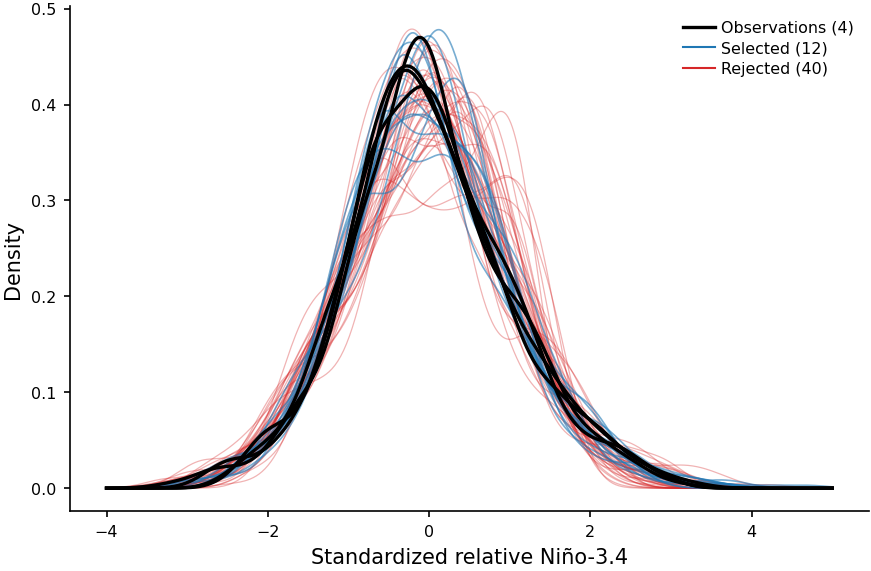

In [24]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

xg = np.linspace(-4, 5, 500)
fig, ax = plt.subplots(figsize=(6, 4))

for m, s in model_rel.items():                                   # rejected
    if m not in gate:
        ax.plot(xg, gaussian_kde(s)(xg), color="tab:red",  lw=0.6, alpha=0.35)
for m in gate:                                                   # selected
    if m in model_rel:
        ax.plot(xg, gaussian_kde(model_rel[m])(xg), color="tab:blue", lw=0.8, alpha=0.6)
for n, s in obs_rel.items():                                    # observations
    ax.plot(xg, gaussian_kde(s)(xg), color="k", lw=1.6)

from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color="k", lw=1.6, label="Observations (4)"),
                   Line2D([0],[0], color="tab:blue", lw=1, label=f"Selected ({len(gate)})"),
                   Line2D([0],[0], color="tab:red",  lw=1, label=f"Rejected ({len(model_rel)-len(gate)})")],
          frameon=False)
ax.set_xlabel("Standardized relative Niño-3.4", fontsize=10); ax.set_ylabel("Density", fontsize=10)
# ax.set_title("Relative Niño-3.4 distribution: obs vs selected vs rejected models")

# ax.errorbar(zc, ax.get_ylim()[1]*0.3, xerr=[[zc - zlo], [zhi - zc]], fmt="*", ms=14,
#             color="navy", mec="navy", capsize=3, lw=1.3, zorder=6, label="2026 forecast")
# ax.set_xlim(right=max(ax.get_xlim()[1], zhi*1.03))



plt.tight_layout(); plt.show()

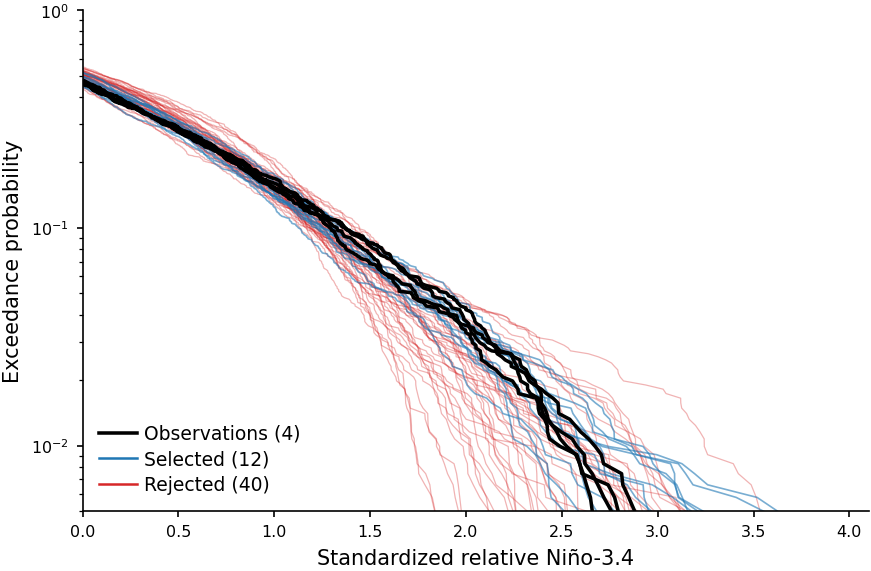

In [25]:
from matplotlib.lines import Line2D

def survival(s):
    x = np.sort(s); return x, 1 - np.arange(1, len(x)+1)/(len(x)+1)

fig, ax = plt.subplots(figsize=(6, 4))
for m, s in model_rel.items():
    if m not in gate:
        x, p = survival(s); ax.plot(x, p, color="tab:red", lw=0.6, alpha=0.35)
for m in gate:
    x, p = survival(model_rel[m]); ax.plot(x, p, color="tab:blue", lw=0.8, alpha=0.6)
for n, s in obs_rel.items():
    x, p = survival(s); ax.plot(x, p, color="k", lw=1.7)

ax.set_yscale("log"); ax.set_xlim(0, 4); ax.set_ylim(5e-3, 1)
ax.set_xlabel("Standardized relative Niño-3.4", fontsize=10)
ax.set_ylabel("Exceedance probability", fontsize=10)
# ax.set_title("Upper-tail exceedance: obs vs selected vs rejected")

ax.legend(handles=[
    Line2D([0], [0], color="k",        lw=1.7, label="Observations (4)"),
    Line2D([0], [0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
    Line2D([0], [0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})"),
], frameon=False, loc="lower left", fontsize=9)



# ax.errorbar(zc, 1.5e-3, xerr=[[zc - zlo], [zhi - zc]], fmt="*", ms=14,
#             color="navy", mec="navy", capsize=3, lw=1.3, zorder=6, label="2026 forecast")
ax.set_xlim(0, max(4, 4.1))          # extend x if the high whisker runs past 4
# then rebuild the legend to include it:
ax.legend(handles=[Line2D([0],[0], color="k", lw=1.7, label="Observations (4)"),
                   Line2D([0],[0], color="tab:blue", lw=1.2, label=f"Selected ({len(gate)})"),
                   Line2D([0],[0], color="tab:red",  lw=1.2, label=f"Rejected ({len(model_rel)-len(gate)})")],
          frameon=False, loc="lower left", fontsize=9)

plt.tight_layout(); plt.show()

In [26]:
from scipy.stats import kurtosis

rows = [dict(model=m, sel=m in gate, kurt=float(kurtosis(s)),
             p99=float(np.percentile(s, 99)), mx=float(np.max(s)))
        for m, s in model_rel.items()]
d = pd.DataFrame(rows)

o = pd.DataFrame([dict(p99=float(np.percentile(s, 99)), mx=float(np.max(s)),
                       kurt=float(kurtosis(s))) for s in obs_rel.values()],
                 index=list(obs_rel))
print("observed:\n", o.round(2).to_string(), "\n")
print("obs range   p99 %.2f–%.2f   max %.2f–%.2f   kurt %.2f–%.2f\n" %
      (o["p99"].min(), o["p99"].max(), o["mx"].min(), o["mx"].max(),
       o["kurt"].min(), o["kurt"].max()))

sel = d[d["sel"]].sort_values("mx", ascending=False)
sel["outside"] = np.where(sel["mx"] > o["mx"].max(), "\u2190 beyond obs", "")
print(sel.round(2).to_string(index=False))

observed:
           p99    mx  kurt
COBE     2.49  3.01  0.24
DCSST    2.64  3.34  0.25
HadISST  2.43  3.13  0.39
ERSSTv5  2.55  3.14  0.03 

obs range   p99 2.43–2.64   max 3.01–3.34   kurt 0.03–0.39

           model  sel  kurt  p99   mx      outside
     SAM0-UNICON True  1.70 2.59 4.72 ← beyond obs
     FIO-ESM-2-0 True  0.95 2.65 3.88 ← beyond obs
    E3SM-1-1-ECA True  0.25 2.45 3.81 ← beyond obs
     CESM2-WACCM True  0.48 2.58 3.71 ← beyond obs
           NESM3 True  0.68 2.77 3.68 ← beyond obs
          MIROC6 True  0.53 2.76 3.62 ← beyond obs
   MPI-ESM1-2-LR True -0.17 2.38 3.62 ← beyond obs
EC-Earth3-Veg-LR True  0.86 2.74 3.58 ← beyond obs
       EC-Earth3 True  0.49 2.62 3.25             
    CMCC-CM2-HR4 True  0.01 2.58 2.93             
      MRI-ESM2-0 True -0.32 2.34 2.79             
 CESM2-WACCM-FV2 True -0.18 2.25 2.74             


## GEV fit and attribution analysis

In [27]:
# BASE_MOD = slice("1991", "2020")          # fixed modern baseline, entirely within historical
# PI, CUR  = slice("1850", "1900"), slice("2000", "2050")


# def obs_oni_std(n):                                   # obs RONI std = obs ONI std (by construction)
#     da  = std_obs(open_obs(n)).sel(time=slice("1900","2000"))
#     n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
#     oni = (n34.groupby("time.month") - n34.groupby("time.month").mean("time")).rolling(time=3, center=True).mean()
#     return float(oni.std())
# SIGMA_OBS = float(np.mean([obs_oni_std(n) for n in obs_files]))
# print(f"SIGMA_OBS (observed RONI std, 1900–2000) = {SIGMA_OBS:.3f}")

# def std_coords(ds):
#     da = ds["ts"]; ren = {}
#     for c in list(da.coords):
#         cl = c.lower()
#         if cl in ("latitude","lat","y"):  ren[c] = "lat"
#         elif cl in ("longitude","lon","x"): ren[c] = "lon"
#     da = da.rename(ren)
#     return da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")

# def model_indices(m):
#     files = hist[m]["files"] + avail["ssp245"][m]["files"]
#     ds = xr.open_mfdataset(files, combine="by_coords", use_cftime=True, chunks={"time": 240})
#     da = std_coords(ds)
#     ocean = np.isnan(_LAND.mask(da.lon, da.lat))

#     n34 = da.sel(lat=slice(-5, 5), lon=slice(190, 240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat", "lon"))
#     bnd = da.sel(lat=slice(-20, 20)); ob = ocean.sel(lat=slice(-20, 20))
#     trp = bnd.where(ob).weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat", "lon"))

#     n34 = n34.compute(); trp = trp.compute()
#     cn = n34.sel(time=BASE_MOD).groupby("time.month").mean("time")
#     ct = trp.sel(time=BASE_MOD).groupby("time.month").mean("time")
#     n34a = n34.groupby("time.month") - cn
#     trpa = trp.groupby("time.month") - ct
#     oni = n34a.rolling(time=3, center=True).mean()
#     rel = (n34a - trpa).rolling(time=3, center=True).mean()
#     return oni, rel


# def event_peaks(roni):
#     """One peak per ENSO year (Jul–Jun) = event magnitude."""
#     roni = roni.dropna("time")
#     mon  = roni["time"].dt.month.values
#     yr   = roni["time"].dt.year.values
#     eyr  = np.where(mon >= 7, yr, yr - 1)
#     return pd.Series(roni.values, index=eyr).groupby(level=0).max().values


In [28]:
# idx = {}
# for m in tqdm([g for g in gate if g in avail["ssp245"]], desc="models"):
#     try:
#         idx[m] = model_indices(m)
#     except Exception as e:
#         tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:60]}")
# print(f"\n{len(idx)} models with historical+ssp245")

# # amplitude factors (match observed ENSO std over 1900–2000), separately per index
# f_oni = {m: SIGMA_OBS / float(o.sel(time=slice("1900","2000")).std()) for m, (o, r) in idx.items()}
# f_rel = {m: SIGMA_OBS / float(r.sel(time=slice("1900","2000")).std()) for m, (o, r) in idx.items()}

# peaks = {"ONI": {}, "RONI": {}}
# for m, (o, r) in idx.items():
#     peaks["ONI"][m]  = {"PI": event_peaks(o.sel(time=PI)*f_oni[m]),
#                         "CUR": event_peaks(o.sel(time=CUR)*f_oni[m])}
#     peaks["RONI"][m] = {"PI": event_peaks(r.sel(time=PI)*f_rel[m]),
#                         "CUR": event_peaks(r.sel(time=CUR)*f_rel[m])}

# for k in peaks:
#     n_pi  = sum(len(v["PI"])  for v in peaks[k].values())
#     n_cur = sum(len(v["CUR"]) for v in peaks[k].values())
#     print(f"{k}: {n_pi} PI event-years, {n_cur} current event-years")
# print("\namplitude factors (ONI):")
# print(pd.Series(f_oni).round(2).sort_values().to_string())

In [29]:
# BASE_OBS = slice("1991", "2020")

# def obs_indices(n):
#     da  = std_obs(open_obs(n))
#     n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon"), skipna=True)
#     bnd = da.sel(lat=slice(-20,20))
#     trp = bnd.weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon"), skipna=True)
#     n34a = n34.groupby("time.month") - n34.sel(time=BASE_OBS).groupby("time.month").mean("time")
#     trpa = trp.groupby("time.month") - trp.sel(time=BASE_OBS).groupby("time.month").mean("time")
#     oni  = n34a.rolling(time=3, center=True).mean()
#     rel  = (n34a - trpa).rolling(time=3, center=True).mean()
#     return oni.compute(), (rel * float(oni.std()) / float(rel.std())).compute()

# def peak_in(series, yr):
#     s = series.sel(time=slice(f"{yr}-07", f"{yr+1}-06"))
#     return float(s.max())

# EVENTS = [1982, 1997, 2015]
# obs_thr = {"ONI": {}, "RONI": {}}
# oi = {n: obs_indices(n) for n in obs_files}
# for yr in EVENTS:
#     obs_thr["ONI"][yr]  = np.mean([peak_in(o, yr) for o, r in oi.values()])
#     obs_thr["RONI"][yr] = np.mean([peak_in(r, yr) for o, r in oi.values()])

# print(f"{'event':10s} {'ONI':>7s} {'RONI':>7s}   (1985\u20132014 baseline, 4-product mean)")
# for yr in EVENTS:
#     print(f"  {yr}\u2013{str(yr+1)[-2:]}  {obs_thr['ONI'][yr]:7.2f} {obs_thr['RONI'][yr]:7.2f}")

# # quick look at how many exceedances the empirical samples actually contain
# for k in ("ONI", "RONI"):
#     for yr in EVENTS:
#         t = obs_thr[k][yr]
#         npi  = sum((v["PI"]  >= t).sum() for v in peaks[k].values())
#         ncur = sum((v["CUR"] >= t).sum() for v in peaks[k].values())
#         print(f"{k:5s} {yr}: threshold {t:.2f}  PI {npi:3d}/520   CUR {ncur:3d}/520")

In [30]:
# import json
# f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))
# # z-scored axes → express forecast in std units (mean≈0, std = SIGMA_OBS)
# # zc, zlo, zhi = (f2026[k] / SIGMA_OBS for k in ("best", "low", "high"))
# # print(f"forecast in std units: central {zc:.2f}  ({zlo:.2f}–{zhi:.2f})")

In [29]:
# from scipy.stats import genextreme as gev

# def pex(x, thr):
#     """P(exceed thr) from a GEV fitted to annual peaks."""
#     c, loc, sc = gev.fit(x)
#     return float(gev.sf(thr, c, loc=loc, scale=sc))

# def ret_level(x, p):
#     c, loc, sc = gev.fit(x)
#     return float(gev.isf(p, c, loc=loc, scale=sc))

# def attribute(pk, thr, n_boot=1000, seed=0):
#     """Probability ratio and intensity change, with model-block bootstrap CIs."""
#     ms = list(pk)
#     pi  = np.concatenate([pk[m]["PI"]  for m in ms])
#     cur = np.concatenate([pk[m]["CUR"] for m in ms])
#     p0, p1 = pex(pi, thr), pex(cur, thr)
#     pr, di = p1/p0, ret_level(cur, p0) - thr

#     rng, PR, DI = np.random.default_rng(seed), [], []
#     for _ in range(n_boot):
#         s = rng.choice(ms, size=len(ms), replace=True)
#         a = np.concatenate([pk[m]["PI"]  for m in s])
#         b = np.concatenate([pk[m]["CUR"] for m in s])
#         try:
#             q0, q1 = pex(a, thr), pex(b, thr)
#             if q0 > 0:
#                 PR.append(q1/q0); DI.append(ret_level(b, q0) - thr)
#         except Exception:
#             pass
#     return dict(P_PI=p0, P_CUR=p1, PR=pr,
#                 PR_lo=np.percentile(PR, 5), PR_hi=np.percentile(PR, 95),
#                 dI=di, dI_lo=np.percentile(DI, 5), dI_hi=np.percentile(DI, 95))


# lab = {y: f"{y}-{str(y+1)[-2:]}" for y in EVENTS}
# thresholds = {"ONI":  {lab[y]: obs_thr["ONI"][y]  for y in EVENTS},
#               "RONI": {**{lab[y]: obs_thr["RONI"][y] for y in EVENTS},
#                        "2026-27 fcst": f2026["best"]}}


# HDR_CI = "[5-95%]"
# HDR_DI = "dI (degC)"
# print(f"{'index':5s} {'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_cur':>7s} "
#       f"{'PR':>6s} {HDR_CI:>15s} {HDR_DI:>10s}")

# res = {}
# for k, ev in thresholds.items():
#     for name, thr in ev.items():
#         r = attribute(peaks[k], thr); res[(k, name)] = r
#         ci = f"[{r['PR_lo']:.1f}-{r['PR_hi']:.1f}]"
#         print(f"{k:5s} {name:14s} {thr:5.2f} {1/r['P_PI']:7.0f} {1/r['P_CUR']:7.0f} "
#               f"{r['PR']:6.1f} {ci:>15s} {r['dI']:+10.2f}")

In [31]:
# def get_clim(m):
#     ds = xr.open_mfdataset(hist[m]["files"], combine="by_coords",
#                            use_cftime=True, chunks={"time": 240})
#     da = std_coords(ds).sel(time=BASE_MOD)
#     ocean = np.isnan(_LAND.mask(da.lon, da.lat))
#     n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon")).compute()
#     bnd = da.sel(lat=slice(-20,20)); ob = ocean.sel(lat=slice(-20,20))
#     trp = bnd.where(ob).weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon")).compute()
#     return (n34.groupby("time.month").mean("time"), trp.groupby("time.month").mean("time"))

# clim_hist = {}
# for m in tqdm([g for g in idx if g in avail["piControl"]], desc="hist clim"):
#     clim_hist[m] = get_clim(m)
# print(f"{len(clim_hist)} models with piControl + historical + ssp245")

In [32]:
# def pic_indices(m):
#     ds = xr.open_mfdataset(avail["piControl"][m]["files"], combine="by_coords",
#                            use_cftime=True, chunks={"time": 240})
#     da = std_coords(ds); ocean = np.isnan(_LAND.mask(da.lon, da.lat))
#     n34 = da.sel(lat=slice(-5,5), lon=slice(190,240))
#     n34 = n34.weighted(np.cos(np.deg2rad(n34.lat))).mean(("lat","lon")).compute()
#     bnd = da.sel(lat=slice(-20,20)); ob = ocean.sel(lat=slice(-20,20))
#     trp = bnd.where(ob).weighted(np.cos(np.deg2rad(bnd.lat))).mean(("lat","lon")).compute()
#     cn, ct = clim_hist[m]
#     n34a = n34.groupby("time.month") - cn
#     trpa = trp.groupby("time.month") - ct
#     return (n34a.rolling(time=3, center=True).mean(),
#             (n34a - trpa).rolling(time=3, center=True).mean())

# for m in tqdm(list(clim_hist), desc="piControl"):
#     try:
#         o, r = pic_indices(m)
#         peaks["ONI"][m]["PI"]  = event_peaks(o * f_oni[m])
#         peaks["RONI"][m]["PI"] = event_peaks(r * f_rel[m])
#     except Exception as e:
#         tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:60]}")

# for k in peaks:
#     keep = {m: v for m, v in peaks[k].items() if m in clim_hist}
#     peaks[k] = keep
#     print(f"{k}: {sum(len(v['PI']) for v in keep.values())} PI yr, "
#           f"{sum(len(v['CUR']) for v in keep.values())} current yr, {len(keep)} models")

# # offset check: piControl should sit COLDER than the modern baseline
# print("\nmean piControl ONI peak (should be well below current):")
# for m, v in list(peaks["ONI"].items())[:5]:
#     print(f"  {m:20s} PI {v['PI'].mean():+.2f}   CUR {v['CUR'].mean():+.2f}")

In [33]:
# from scipy.stats import genextreme as gev

# def pex(x, thr):
#     """P(exceed thr) from a GEV fitted to annual peaks."""
#     c, loc, sc = gev.fit(x)
#     return float(gev.sf(thr, c, loc=loc, scale=sc))

# def ret_level(x, p):
#     c, loc, sc = gev.fit(x)
#     return float(gev.isf(p, c, loc=loc, scale=sc))

# def attribute(pk, thr, n_boot=1000, seed=0):
#     """Probability ratio and intensity change, with model-block bootstrap CIs."""
#     ms = list(pk)
#     pi  = np.concatenate([pk[m]["PI"]  for m in ms])
#     cur = np.concatenate([pk[m]["CUR"] for m in ms])
#     p0, p1 = pex(pi, thr), pex(cur, thr)
#     pr, di = p1/p0, ret_level(cur, p0) - thr

#     rng, PR, DI = np.random.default_rng(seed), [], []
#     for _ in range(n_boot):
#         s = rng.choice(ms, size=len(ms), replace=True)
#         a = np.concatenate([pk[m]["PI"]  for m in s])
#         b = np.concatenate([pk[m]["CUR"] for m in s])
#         try:
#             q0, q1 = pex(a, thr), pex(b, thr)
#             if q0 > 0:
#                 PR.append(q1/q0); DI.append(ret_level(b, q0) - thr)
#         except Exception:
#             pass
#     return dict(P_PI=p0, P_CUR=p1, PR=pr,
#                 PR_lo=np.percentile(PR, 5), PR_hi=np.percentile(PR, 95),
#                 dI=di, dI_lo=np.percentile(DI, 5), dI_hi=np.percentile(DI, 95))


# lab = {y: f"{y}-{str(y+1)[-2:]}" for y in EVENTS}
# thresholds = {"ONI":  {lab[y]: obs_thr["ONI"][y]  for y in EVENTS},
#               "RONI": {**{lab[y]: obs_thr["RONI"][y] for y in EVENTS},
#                        "2026-27 fcst": f2026["best"]}}

In [47]:
# fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL, 90*MM), sharey=False)
# for ax, k in zip(axes, ["ONI", "RONI"]):
#     for lbl, col in [("PI", "0.35"), ("CUR", "tab:red")]:
#         x = np.concatenate([v[lbl] for v in peaks[k].values()])
#         xs = np.sort(x)[::-1]
#         rp = (len(xs)+1)/np.arange(1, len(xs)+1)
#         ax.plot(rp, xs, ".", ms=2.5, color=col, alpha=0.5)
#         c, loc, sc = gev.fit(x)
#         pgrid = np.logspace(np.log10(1/len(xs)/3), np.log10(0.6), 200)
#         ax.plot(1/pgrid, gev.isf(pgrid, c, loc=loc, scale=sc), "-", color=col, lw=1.6,
#                 label=f"{lbl} (GEV, c={c:+.2f})")
#     for name, t in thresholds[k].items():
#         ax.axhline(t, color="navy", lw=0.7, ls=":")
#         ax.text(1.1, t+0.03, name, fontsize=6, color="navy")
#     ax.set_xscale("log"); ax.set_xlabel("Return period (yr)"); ax.set_title(k)
#     ax.legend(fontsize=7)
# axes[0].set_ylabel("Event-peak (\u00b0C)")
# plt.tight_layout()

In [52]:
# fig, ax = plt.subplots(figsize=(SINGLE_COL*1.35, 110*MM))
# k = "RONI"
# fits = {}
# for lbl, name, col in [("PI", "piControl counterfactual", "0.35"), ("CUR", "hist+ssp245 (2000\u20132050)", "#c1272d")]:
#     x  = np.concatenate([v[lbl] for v in peaks[k].values()])
#     xs = np.sort(x)[::-1]
#     rp = (len(xs)+1)/np.arange(1, len(xs)+1)
#     ax.plot(rp, xs, ".", ms=2.5, color=col, alpha=0.45, zorder=2)
#     c, loc, sc = gev.fit(x); fits[lbl] = (c, loc, sc)
#     pg = np.logspace(np.log10(1/len(xs)/3), np.log10(0.6), 300)
#     ax.plot(1/pg, gev.isf(pg, c, loc=loc, scale=sc), "-", color=col, lw=1.8,
#             zorder=3, label=f"{name}  (n={len(xs)})")

# # event thresholds, labels staggered on the right
# order = sorted(thresholds[k].items(), key=lambda kv: kv[1])
# for i, (name, t) in enumerate(order):
#     ax.axhline(t, color="navy", lw=0.6, ls=":", zorder=1)
#     ax.text(2.2e4, t, name, fontsize=5, color="navy", va="center", ha="left")

# def gev_band(x, models_dict, lbl, n_boot=300, seed=0):
#     ms, rng = list(models_dict), np.random.default_rng(seed)
#     pg = np.logspace(-4.3, np.log10(0.6), 200); curves = []
#     for _ in range(n_boot):
#         s = rng.choice(ms, size=len(ms), replace=True)
#         try:
#             f = gev.fit(np.concatenate([models_dict[m][lbl] for m in s]))
#             curves.append(gev.isf(pg, *f))
#         except Exception: pass
#     c = np.array(curves)
#     return 1/pg, np.percentile(c, 5, axis=0), np.percentile(c, 95, axis=0)

# # for lbl, col in [("PI", "0.35"), ("CUR", "#c1272d")]:
# #     rpb, lo, hi = gev_band(None, peaks["RONI"], lbl)
# #     ax.fill_between(rpb, lo, hi, color=col, alpha=0.15, lw=0, zorder=1)

# for lbl, col in [("PI", "0.35"), ("CUR", "#c1272d")]:
#     rng = np.random.default_rng(1); ms = list(peaks[k]); curves = []
#     pg = np.logspace(-4.3, np.log10(0.6), 200)
#     for _ in range(300):
#         s = rng.choice(ms, len(ms), replace=True)
#         try: curves.append(gev.isf(pg, *gev.fit(np.concatenate([peaks[k][m][lbl] for m in s]))))
#         except Exception: pass
#     c = np.array(curves)
#     ax.fill_between(1/pg, np.percentile(c, 5, axis=0), np.percentile(c, 95, axis=0),
#                     color=col, alpha=0.15, lw=0, zorder=1)

# ax.set_xscale("log"); ax.set_xlim(1, 2e4); ax.set_ylim(-0.5, 4.2)
# ax.set_xlabel("Return period (ENSO years)")
# ax.set_ylabel("Event-peak RONI (\u00b0C)")
# ax.legend(loc="upper left", fontsize=8)
# ax.spines[["top", "right"]].set_visible(False)
# plt.tight_layout()

# # numbers to quote alongside
# print(f"{'event':14s} {'thr':>5s} {'RP_PI':>8s} {'RP_cur':>8s} {'PR':>7s}")
# for name, t in order:
#     p0 = float(gev.sf(t, *fits["PI"])); p1 = float(gev.sf(t, *fits["CUR"]))
#     print(f"  {name:12s} {t:5.2f} {1/p0:8.0f} {1/p1:8.0f} {p1/p0:7.1f}")


In [36]:
# ============================ CONFIGURATION ============================
# All period/threshold choices live here so the analysis can be re-run
# under different assumptions by editing this cell alone.

BASE     = slice("1991", "2020")   # WMO normal; anomaly baseline for models AND obs.
                                   # A FIXED common baseline is essential: if each
                                   # period were anomalised to its own mean, the
                                   # warming signal would be removed by construction.
CUR      = slice("2000", "2050")   # "current climate" sample (historical + scenario)
CALIB    = slice("1900", "2000")   # period used to match model ENSO amplitude to obs
SCENARIO = "ssp245"                # fills 2015-2050
EVENTS   = [1982, 1997, 2015]      # observed events used as attribution thresholds

N34 = dict(lat=slice(-5, 5),   lon=slice(190, 240))   # Nino-3.4 box
TRP = dict(lat=slice(-20, 20), lon=slice(0, 360))     # tropical belt (ocean only)
DATA = "/g/data/if69/as8561/data"

In [63]:
# ======================== SHARED HELPER FUNCTIONS ======================
import numpy as np, pandas as pd, xarray as xr
from tqdm.auto import tqdm

def std_coords(ds, var="ts"):
    """Rename lat/lon to a common convention and put longitude on 0-360."""
    da = ds[var]
    ren = {c: ("lat" if c.lower() in ("latitude","lat","y") else "lon")
           for c in da.coords if c.lower() in ("latitude","lat","y","longitude","lon","x")}
    da = da.rename(ren)
    return da.assign_coords(lon=(da["lon"] % 360)).sortby("lon").sortby("lat")

def area_mean(da, box, ocean=None):
    """Cosine-weighted area mean over a lat/lon box, optionally ocean-masked."""
    b = da.sel(**box)
    if ocean is not None:
        b = b.where(ocean.sel(lat=box["lat"]))
    return b.weighted(np.cos(np.deg2rad(b.lat))).mean(("lat", "lon"), skipna=True)

def make_indices(n34, trp, clim=None):
    """Build ONI and RONI from Nino-3.4 and tropical-mean SST series.

    ONI  = 3-month running mean of the Nino-3.4 anomaly
    RONI = 3-month running mean of (Nino-3.4 anomaly - tropical-mean anomaly)
    `clim` supplies an EXTERNAL (cn, ct) monthly climatology - used for piControl,
    which has no calendar overlap with the baseline but must share its reference
    so the pre-industrial cold offset is retained.
    """
    cn, ct = clim if clim is not None else (n34.sel(time=BASE).groupby("time.month").mean("time"),
                                            trp.sel(time=BASE).groupby("time.month").mean("time"))
    n34a = n34.groupby("time.month") - cn
    trpa = trp.groupby("time.month") - ct
    return (n34a.rolling(time=3, center=True).mean(),
            (n34a - trpa).rolling(time=3, center=True).mean())

def event_peaks(idx, min_months=12):
    """Annual block maxima: one peak per complete ENSO year (Jul-Jun).

    Incomplete years at the ends of a period are dropped - their maxima
    cannot include the DJF peak season and would bias the distribution low.
    """
    idx = idx.dropna("time")
    yr  = idx["time"].dt.year.values
    eyr = np.where(idx["time"].dt.month.values >= 7, yr, yr - 1)
    s   = pd.Series(idx.values, index=eyr)
    g   = s.groupby(level=0)
    return g.max()[g.size() >= min_months].values

In [64]:
# ================= OBSERVATIONS: amplitude target + thresholds =================
def obs_indices(name):
    """Observed ONI and RONI for one SST product, on the common baseline.
    RONI is rescaled so its variance matches ONI - the operational CPC definition.
    """
    da  = std_obs(open_obs(name))
    n34, trp = area_mean(da, N34), area_mean(da, TRP)
    oni, rel = make_indices(n34, trp)
    return oni.compute(), (rel * float(oni.std()) / float(rel.std())).compute()

oi = {n: obs_indices(n) for n in obs_files}

# Observed ENSO amplitude: the target every model is rescaled to.
SIGMA_OBS = float(np.mean([float(o.sel(time=CALIB).std()) for o, r in oi.values()]))

def peak_in(series, yr):
    """Peak index value within one ENSO year (Jul yr - Jun yr+1)."""
    return float(series.sel(time=slice(f"{yr}-07", f"{yr+1}-06")).max())

# Attribution thresholds = observed event peaks, averaged across products.
obs_thr = {k: {yr: np.mean([peak_in(v[i], yr) for v in oi.values()]) for yr in EVENTS}
           for i, k in enumerate(["ONI", "RONI"])}

import json
f2026 = json.load(open(f"{DATA}/f2026_roni_forecast.json"))
lab = {y: f"{y}-{str(y+1)[-2:]}" for y in EVENTS}
thresholds = {"ONI":  {lab[y]: obs_thr["ONI"][y]  for y in EVENTS},
              "RONI": {**{lab[y]: obs_thr["RONI"][y] for y in EVENTS},
                       "2026-27 fcst": f2026["best"]}}

print(f"SIGMA_OBS = {SIGMA_OBS:.3f} degC")
print(pd.DataFrame(obs_thr).round(2).to_string())

SIGMA_OBS = 0.789 degC
       ONI  RONI
1982  2.22  2.65
1997  2.39  2.42
2015  2.62  2.48


In [65]:
# ============ MODELS: current-climate indices (historical + scenario) ============
def model_indices(m, files, clim=None):
    """Compute ONI/RONI for one model from a list of files.
    Land is masked before the tropical mean because `ts` is skin temperature
    (i.e. includes land), which would otherwise contaminate the RONI reference.
    """
    ds = xr.open_mfdataset(files, combine="by_coords", use_cftime=True, chunks={"time": 240})
    da = std_coords(ds)
    ocean = np.isnan(_LAND.mask(da.lon, da.lat))
    n34 = area_mean(da, N34).compute()
    trp = area_mean(da, TRP, ocean).compute()
    return make_indices(n34, trp, clim), (n34, trp)

models = [m for m in gate if m in avail[SCENARIO] and m in avail["piControl"]]
idx, clim_hist = {}, {}
for m in tqdm(models, desc="historical+scenario"):
    try:
        (oni, rel), (n34, trp) = model_indices(m, hist[m]["files"] + avail[SCENARIO][m]["files"])
        idx[m] = (oni, rel)
        # store this model's baseline climatology - reused for piControl
        clim_hist[m] = (n34.sel(time=BASE).groupby("time.month").mean("time"),
                        trp.sel(time=BASE).groupby("time.month").mean("time"))
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:60]}")
print(f"\n{len(idx)} models with historical + {SCENARIO} + piControl")

historical+scenario:   0%|          | 0/8 [00:00<?, ?it/s]


8 models with historical + ssp245 + piControl


In [66]:
# ================= AMPLITUDE SCALING + CURRENT-CLIMATE PEAKS =================
# One multiplicative factor per model per index, from the calibration period.
# Applied to ALL experiments of that model, so absolute thresholds are
# comparable across models while forced differences between experiments survive.
factor = {k: {m: SIGMA_OBS / float(v[i].sel(time=CALIB).std()) for m, v in idx.items()}
          for i, k in enumerate(["ONI", "RONI"])}

peaks = {"ONI": {}, "RONI": {}}
for m, (oni, rel) in idx.items():
    peaks["ONI"][m]  = {"CUR": event_peaks(oni.sel(time=CUR) * factor["ONI"][m])}
    peaks["RONI"][m] = {"CUR": event_peaks(rel.sel(time=CUR) * factor["RONI"][m])}

print("amplitude factors (should sit within ~0.5-2.0):")
print(pd.DataFrame(factor).round(2).sort_values("ONI").to_string())

amplitude factors (should sit within ~0.5-2.0):
                   ONI  RONI
CESM2-WACCM       0.67  0.81
MIROC6            0.75  0.99
MRI-ESM2-0        0.79  0.93
FIO-ESM-2-0       0.83  1.00
MPI-ESM1-2-LR     0.99  1.33
EC-Earth3-Veg-LR  1.02  1.22
EC-Earth3         1.06  1.32
NESM3             1.09  1.41


In [67]:
# ==================== COUNTERFACTUAL: piControl peaks ====================
# piControl is anomalised against each model's OWN historical baseline
# climatology, not its own mean. This preserves the pre-industrial cold /
# pattern offset, which is exactly the signal being attributed.
for m in tqdm(list(idx), desc="piControl"):
    try:
        (oni, rel), _ = model_indices(m, avail["piControl"][m]["files"], clim=clim_hist[m])
        peaks["ONI"][m]["PI"]  = event_peaks(oni * factor["ONI"][m])
        peaks["RONI"][m]["PI"] = event_peaks(rel * factor["RONI"][m])
    except Exception as e:
        tqdm.write(f"  {m} SKIP {type(e).__name__}: {str(e)[:60]}")

for k in peaks:                                     # keep only complete models
    peaks[k] = {m: v for m, v in peaks[k].items() if {"PI", "CUR"} <= set(v)}
    print(f"{k}: {len(peaks[k])} models | "
          f"{sum(len(v['PI']) for v in peaks[k].values())} PI yr, "
          f"{sum(len(v['CUR']) for v in peaks[k].values())} current yr")

# Sanity check: pre-industrial peaks must sit BELOW current ones.
# If they don't, the baseline offset has not carried through correctly.
print("\nmean event peak (RONI):")
for m, v in peaks["RONI"].items():
    print(f"  {m:20s} PI {v['PI'].mean():+.2f}   CUR {v['CUR'].mean():+.2f}")

piControl:   0%|          | 0/8 [00:00<?, ?it/s]

ONI: 8 models | 4994 PI yr, 400 current yr
RONI: 8 models | 4994 PI yr, 400 current yr

mean event peak (RONI):
  CESM2-WACCM          PI +0.50   CUR +0.87
  EC-Earth3            PI +0.29   CUR +0.73
  EC-Earth3-Veg-LR     PI +0.46   CUR +0.61
  FIO-ESM-2-0          PI +0.17   CUR +0.64
  MIROC6               PI +0.35   CUR +0.65
  MPI-ESM1-2-LR        PI +0.38   CUR +0.54
  MRI-ESM2-0           PI +0.45   CUR +0.58
  NESM3                PI +0.67   CUR +0.59


In [68]:
# ============================ GEV ATTRIBUTION ============================
# Empirical counting fails here: the pre-industrial sample contains only a
# handful of exceedances (sometimes zero), so probability ratios are undefined
# or wildly uncertain. Fitting a GEV to the annual maxima uses the whole
# distribution to constrain the tail, at the cost of a distributional assumption.
from scipy.stats import genextreme as gev

def pool(pk, sel=None, rng=None, equal_weight=True):
    """Pool annual peaks across models.
    piControl runs differ in length (500-2000 yr); equal-weighting subsamples
    each to the shortest so no single long run dominates the counterfactual tail.
    """
    sel = sel or list(pk)
    L   = min(len(pk[m]["PI"]) for m in pk)
    rng = rng or np.random.default_rng(0)
    pi  = np.concatenate([rng.choice(pk[m]["PI"], L, replace=False) if equal_weight
                          else pk[m]["PI"] for m in sel])
    return pi, np.concatenate([pk[m]["CUR"] for m in sel])

def attribute(pk, thrs, n_boot=1000, seed=0, equal_weight=True):
    """Probability ratio and intensity change for each threshold.

    PR = P_current(exceed) / P_preindustrial(exceed)
    dI = magnitude in the current climate at the pre-industrial exceedance
         probability, minus the threshold
    Uncertainty: bootstrap over MODELS (not years), since structural spread
    between models dominates sampling noise.
    """
    ms  = list(pk)
    rng = np.random.default_rng(seed)
    pi, cur = pool(pk, ms, rng, equal_weight)
    f0, f1  = gev.fit(pi), gev.fit(cur)

    out = {t: dict(RP_PI=1/float(gev.sf(t, *f0)), RP_CUR=1/float(gev.sf(t, *f1)),
                   PR=float(gev.sf(t, *f1))/float(gev.sf(t, *f0)),
                   dI=float(gev.isf(float(gev.sf(t, *f0)), *f1)) - t, b=[]) for t in thrs}

    for _ in range(n_boot):
        sel = rng.choice(ms, len(ms), replace=True)
        try:
            a, b = pool(pk, list(sel), rng, equal_weight)
            ga, gb = gev.fit(a), gev.fit(b)
        except Exception:
            continue
        for t in thrs:
            p0 = float(gev.sf(t, *ga))
            if p0 > 0: out[t]["b"].append(float(gev.sf(t, *gb)) / p0)

    for t in thrs:
        out[t]["lo"], out[t]["hi"] = np.percentile(out[t]["b"], [5, 95])
    return out, (f0, f1), (pi, cur)

In [69]:
# ================================ RESULTS ================================
K    = "RONI"                                   # switch to "ONI" for the absolute-event version
thrs = dict(sorted(thresholds[K].items(), key=lambda kv: kv[1]))
res, fits, samples = attribute(peaks[K], list(thrs.values()))

print(f"{K}   ({len(peaks[K])} models, "
      f"PI n={len(samples[0])}, CUR n={len(samples[1])})\n")
print(f"{'event':14s} {'thr':>5s} {'RP_PI':>7s} {'RP_CUR':>7s} {'PR':>7s} "
      f"{'[5-95%]':>15s} {'dI':>7s}")
for name, t in thrs.items():
    r = res[t]
    ci = f"[{r['lo']:.1f}-{r['hi']:.1f}]"
    print(f"  {name:12s} {t:5.2f} {r['RP_PI']:7.0f} {r['RP_CUR']:7.0f} "
          f"{r['PR']:7.1f} {ci:>15s} {r['dI']:+7.2f}")

RONI   (8 models, PI n=3984, CUR n=400)

event            thr   RP_PI  RP_CUR      PR         [5-95%]      dI
  1997-98       2.42     223      30     7.3      [4.0-11.2]   +0.90
  2015-16       2.48     266      34     7.9      [4.2-12.3]   +0.92
  1982-83       2.65     483      48    10.0      [4.9-16.1]   +0.96
  2026-27 fcst  2.93    1340      87    15.4      [6.5-28.0]   +1.03


Pre-industrial (piControl)         KS D=0.026  p=0.010
Current 2000–2050 (ssp245)         KS D=0.031  p=0.831


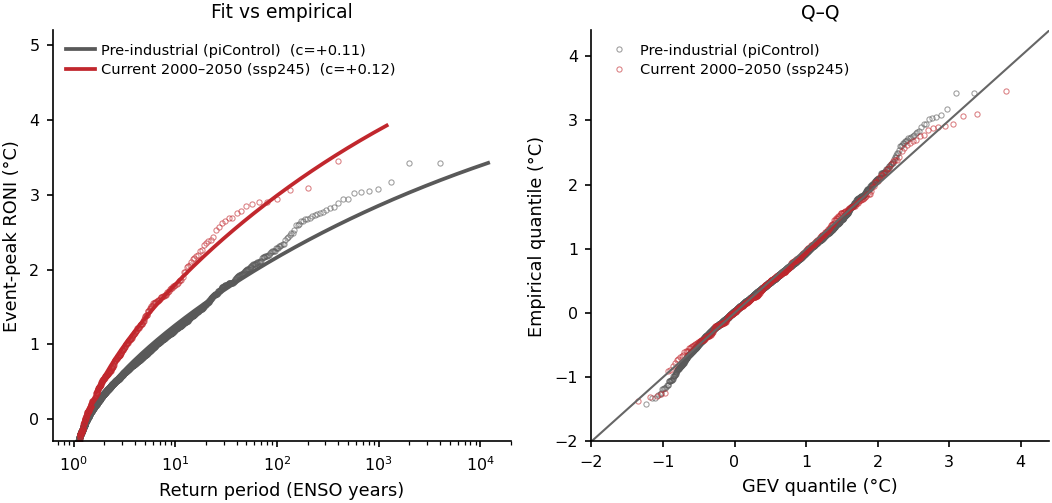

In [73]:
from scipy.stats import kstest

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL*1.0, 90*MM))

# --- (a) return-level: fit vs empirical, zoomed on the tail ---
ax = axes[0]
for lbl, name, col in STY:
    x  = samples[lbl]; f = gfits[lbl]
    xs = np.sort(x)[::-1]
    rp = (len(xs)+1)/np.arange(1, len(xs)+1)
    ax.plot(rp, xs, "o", ms=2.5, mfc="none", mec=col, mew=0.5, alpha=0.6, zorder=2)
    pg = np.logspace(np.log10(1/(len(xs)*3)), np.log10(0.6), 200)
    ax.plot(1/pg, gev.isf(pg, *f), "-", color=col, lw=1.8, zorder=3,
            label=f"{name}  (c={f[0]:+.2f})")
ax.set_xscale("log"); ax.set_xlim(0, 2e4); ax.set_ylim(-0.3, 5.2)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.set_title("Fit vs empirical", fontsize=9)
ax.legend(fontsize=7, frameon=False, loc="upper left")

# --- (b) QQ: empirical quantiles vs GEV quantiles ---
ax = axes[1]
for lbl, name, col in STY:
    x  = np.sort(samples[lbl]); f = gfits[lbl]
    pp = (np.arange(1, len(x)+1) - 0.5)/len(x)          # Hazen plotting positions
    ax.plot(gev.ppf(pp, *f), x, "o", ms=2.5, mfc="none", mec=col, mew=0.5,
            alpha=0.6, label=name)
    ks = kstest(x, lambda q: gev.cdf(q, *f))
    print(f"{name:34s} KS D={ks.statistic:.3f}  p={ks.pvalue:.3f}")
lims = [-2.0, 4.4]
ax.plot(lims, lims, "-", color="0.4", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("GEV quantile (\u00b0C)"); ax.set_ylabel("Empirical quantile (\u00b0C)")
ax.set_title("Q\u2013Q", fontsize=9)
ax.legend(fontsize=7, frameon=False, loc="upper left")

for a in axes: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

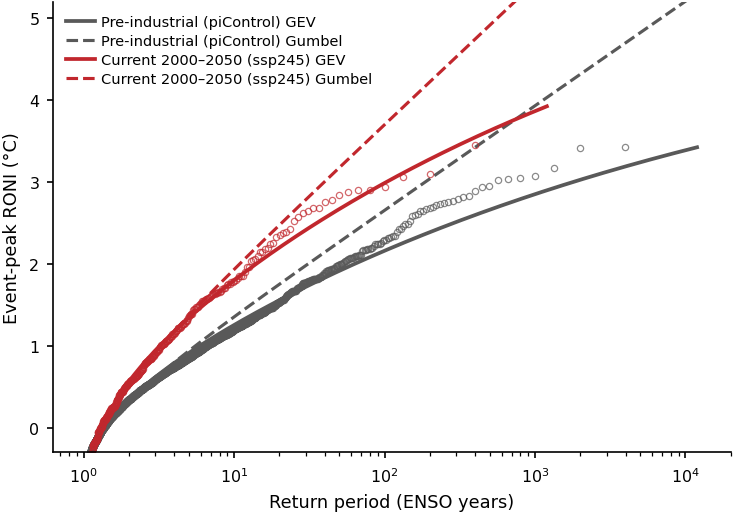

In [76]:
from scipy.stats import gumbel_r

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))
for lbl, name, col in STY:
    x  = samples[lbl]; xs = np.sort(x)[::-1]
    rp = (len(xs)+1)/np.arange(1, len(xs)+1)
    ax.plot(rp, xs, "o", ms=3, mfc="none", mec=col, mew=0.6, alpha=0.7, zorder=2)
    pg = np.logspace(np.log10(1/(len(xs)*3)), np.log10(0.6), 200)
    ax.plot(1/pg, gev.isf(pg, *gev.fit(x)), "-",  color=col, lw=1.8, label=f"{name} GEV")
    ax.plot(1/pg, gumbel_r.isf(pg, *gumbel_r.fit(x)), "--", color=col, lw=1.5,
            label=f"{name} Gumbel")
ax.set_xscale("log"); ax.set_xlim(0, 2e4); ax.set_ylim(-0.3, 5.2)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(fontsize=7, frameon=False, loc="upper left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout()

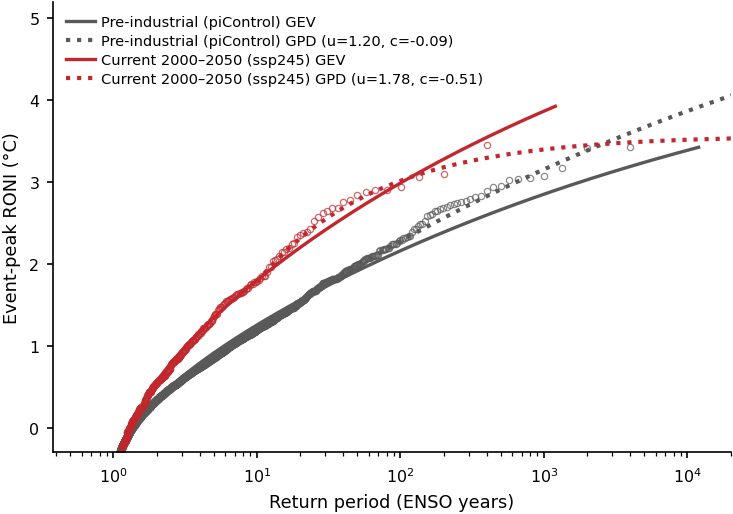

In [81]:
from scipy.stats import genpareto

def pot_fit(x, q=0.90):
    """Peaks-over-threshold: GPD fitted to exceedances above the q-quantile.
    Returns a survival function P(X > val) for the full series."""
    u    = np.quantile(x, q)
    exc  = x[x > u] - u
    c, _, s = genpareto.fit(exc, floc=0)
    zeta = len(exc)/len(x)                      # P(X > u), estimated empirically
    return lambda v: zeta*genpareto.sf(np.asarray(v) - u, c, loc=0, scale=s), (u, c, s, zeta)

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))
for lbl, name, col in STY:
    x = samples[lbl]; xs = np.sort(x)[::-1]
    ax.plot((len(xs)+1)/np.arange(1, len(xs)+1), xs, "o", ms=3,
            mfc="none", mec=col, mew=0.6, alpha=0.7)
    pg = np.logspace(np.log10(1/(len(xs)*3)), np.log10(0.6), 200)
    ax.plot(1/pg, gev.isf(pg, *gev.fit(x)), "-", color=col, lw=1.6, label=f"{name} GEV")
    sf, (u, c, s, z) = pot_fit(x, q=0.90)
    grid = np.linspace(u, x.max()*1.4, 300)
    ax.plot(1/sf(grid), grid, ":", color=col, lw=2.0, label=f"{name} GPD (u={u:.2f}, c={c:+.2f})")
ax.set_xscale("log"); ax.set_xlim(0, 2e4); ax.set_ylim(-0.3, 5.2)
ax.set_xlabel("Return period (ENSO years)"); ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(fontsize=7, frameon=False, loc="upper left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout()

In [83]:
for q in (0.70, 0.80, 0.90, 0.95):
    for lbl, name, _ in STY:
        _, (u, c, s, z) = pot_fit(samples[lbl], q=q)
        print(f"q={q:.2f}  {name:32s} u={u:5.2f}  c={c:+.2f}  n_exc={int(z*len(samples[lbl]))}")

q=0.70  Pre-industrial (piControl)       u= 0.65  c=-0.05  n_exc=1195
q=0.70  Current 2000–2050 (ssp245)       u= 1.01  c=-0.31  n_exc=120
q=0.80  Pre-industrial (piControl)       u= 0.85  c=-0.07  n_exc=797
q=0.80  Current 2000–2050 (ssp245)       u= 1.35  c=-0.35  n_exc=80
q=0.90  Pre-industrial (piControl)       u= 1.20  c=-0.09  n_exc=399
q=0.90  Current 2000–2050 (ssp245)       u= 1.78  c=-0.51  n_exc=40
q=0.95  Pre-industrial (piControl)       u= 1.53  c=-0.20  n_exc=200
q=0.95  Current 2000–2050 (ssp245)       u= 2.33  c=-0.49  n_exc=20


In [84]:
# how much does the PI tail underestimate inflate PR?
sf_pi_gpd, _ = pot_fit(samples["PI"], q=0.90)          # GPD tracks the PI tail well
for name, t in sorted(thresholds[K].items(), key=lambda kv: kv[1]):
    p1  = float(gev.sf(t, *gfits["CUR"]))
    p0g = float(gev.sf(t, *gfits["PI"]))               # GEV pre-industrial
    p0p = float(sf_pi_gpd(t))                          # GPD pre-industrial
    print(f"  {name:14s} PR(GEV) {p1/p0g:6.1f}   PR(GPD-PI) {p1/p0p:6.1f}")

  1997-98        PR(GEV)    7.3   PR(GPD-PI)    4.7
  2015-16        PR(GEV)    7.9   PR(GPD-PI)    4.8
  1982-83        PR(GEV)   10.0   PR(GPD-PI)    5.2
  2026-27 fcst   PR(GEV)   15.4   PR(GPD-PI)    6.0


Pre-industrial (piControl)         RP(forecast 2.93) =    1340 yr
Current 2000–2050 (ssp245)         RP(forecast 2.93) =      87 yr


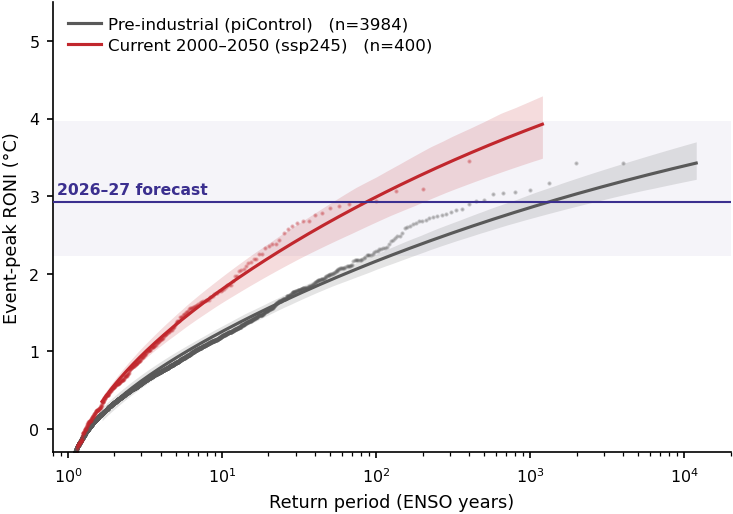

In [86]:
FC = "#3b2f8f"                                   # forecast colour, matching the obs figure
K  = "RONI"
rng = np.random.default_rng(0)
ms  = list(peaks[K])
L   = min(len(peaks[K][m]["PI"]) for m in ms)

samples = {"PI":  np.concatenate([rng.choice(peaks[K][m]["PI"], L, replace=False) for m in ms]),
           "CUR": np.concatenate([peaks[K][m]["CUR"] for m in ms])}
gfits   = {lbl: gev.fit(x) for lbl, x in samples.items()}

STY = [("PI",  "Pre-industrial (piControl)", "0.35"),
       ("CUR", f"Current 2000\u20132050 ({SCENARIO})", "#c1272d")]

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))

# forecast magnitude: central estimate + 5-95% range
ax.axhspan(f2026["low"], f2026["high"], color=FC, alpha=0.05, lw=0, zorder=0)
ax.axhline(f2026["best"], color=FC, lw=1.0, zorder=4)
ax.text(0.85, f2026["best"] + 0.06, "2026\u201327 forecast", color=FC,
        fontsize=7.5, fontweight="bold", va="bottom", ha="left")

for lbl, name, col in STY:
    n  = len(samples[lbl])
    pg = np.logspace(np.log10(1/(n*3)), np.log10(0.6), 200)     # one grid: band and line match

    curves = []                                                  # model-block bootstrap band
    for _ in range(300):
        s = rng.choice(ms, len(ms), replace=True)
        x = np.concatenate([rng.choice(peaks[K][m]["PI"], L, replace=False) if lbl == "PI"
                            else peaks[K][m]["CUR"] for m in s])
        try: curves.append(gev.isf(pg, *gev.fit(x)))
        except Exception: pass
    c = np.array(curves)
    ax.fill_between(1/pg, np.percentile(c, 5, 0), np.percentile(c, 95, 0),
                    color=col, alpha=0.16, lw=0, zorder=1)

    xs = np.sort(samples[lbl])[::-1]                             # empirical points
    ax.plot((len(xs)+1)/np.arange(1, len(xs)+1), xs, ".", ms=2,
            color=col, alpha=0.30, zorder=2)
    ax.plot(1/pg, gev.isf(pg, *gfits[lbl]), "-", color=col, lw=1.5, zorder=3,
            label=f"{name}   (n={n})")

ax.set_xscale("log"); ax.set_xlim(0.8, 2e4); ax.set_ylim(-0.3, 5.5)
ax.set_xlabel("Return period (ENSO years)")
ax.set_ylabel("Event-peak RONI (\u00b0C)")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

# return periods of the forecast magnitude in each climate
for lbl, name, _ in STY:
    print(f"{name:34s} RP(forecast {f2026['best']:.2f}) = "
          f"{1/float(gev.sf(f2026['best'], *gfits[lbl])):7.0f} yr")

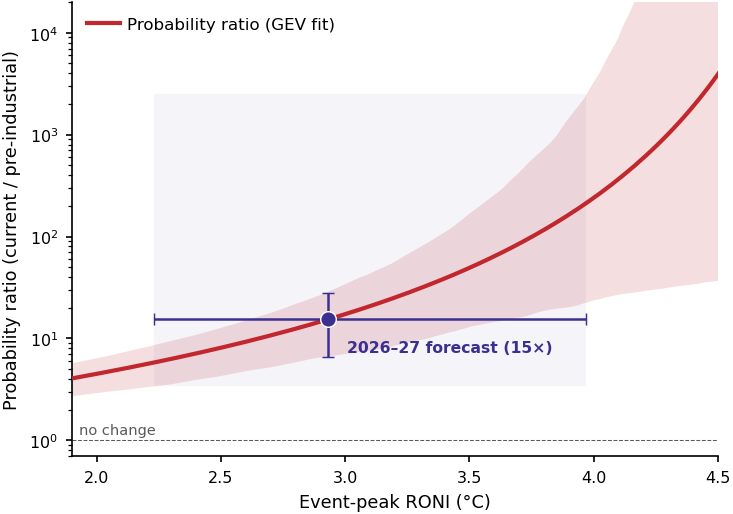

In [82]:
K = "RONI"
mags = np.linspace(1.9, 5.5, 160)
f0, f1 = gfits["PI"], gfits["CUR"]

p0 = gev.sf(mags, *f0)
valid = p0 > 0                                   # PI tail is bounded: PR undefined beyond it
pr_c = np.where(valid, gev.sf(mags, *f1)/np.where(valid, p0, np.nan), np.nan)

rng, curves = np.random.default_rng(0), []
for _ in range(500):
    s = rng.choice(ms, len(ms), replace=True)
    try:
        ga = gev.fit(np.concatenate([rng.choice(peaks[K][m]["PI"], L, replace=False) for m in s]))
        gb = gev.fit(np.concatenate([peaks[K][m]["CUR"] for m in s]))
        with np.errstate(divide="ignore", invalid="ignore"):
            q0 = gev.sf(mags, *ga)
            curves.append(np.where(q0 > 0, gev.sf(mags, *gb)/np.where(q0 > 0, q0, np.nan), np.nan))
    except Exception: pass
C = np.array(curves)
lo_b, hi_b = np.nanpercentile(C, 5, 0), np.nanpercentile(C, 95, 0)

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.45, 92*MM))
ax.fill_between(mags, lo_b, hi_b, color="#c1272d", alpha=0.15, lw=0, zorder=1)
ax.plot(mags, pr_c, color="#c1272d", lw=2, zorder=4, label="Probability ratio (GEV fit)")
ax.axhline(1, color="0.35", lw=0.5, ls="--", zorder=2)
ax.text(mags[0]+0.03, 1.07, "no change", fontsize=7, color="0.35", va="bottom")

# --- forecast only ---
fb, flo, fhi = f2026["best"], f2026["low"], f2026["high"]
pr_f = float(gev.sf(fb, *f1))/float(gev.sf(fb, *f0))
rf   = res[fb]
tot_lo = np.interp(flo, mags, lo_b)
tot_hi = np.interp(fhi, mags, hi_b)

ax.add_patch(plt.Rectangle((flo, tot_lo), fhi-flo, tot_hi-tot_lo,
                           facecolor=FC, alpha=0.05, lw=0, zorder=3))
ax.errorbar(fb, pr_f, xerr=[[fb-flo], [fhi-fb]], yerr=[[pr_f-rf["lo"]], [rf["hi"]-pr_f]],
            fmt="o", ms=7.5, color=FC, mec="w", mew=0.7, ecolor=FC,
            capsize=3, lw=1.2, zorder=7)
ax.annotate(f"2026\u201327 forecast ({pr_f:.0f}\u00d7)", (fb, pr_f), xytext=(9, -10),
            textcoords="offset points", fontsize=7.5, color=FC,
            fontweight="bold", ha="left", va="top")

ax.set_yscale("log"); ax.set_xlim(mags[0], 4.5); ax.set_ylim(0.7, 2e4)
ax.set_xlabel("Event-peak RONI (\u00b0C)")
ax.set_ylabel("Probability ratio (current / pre-industrial)")
ax.legend(loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [45]:
for m in list(peaks["RONI"])[:6]:
    print(f"{m:20s} PI mean {peaks['RONI'][m]['PI'].mean():+.2f}   "
          f"CUR mean {peaks['RONI'][m]['CUR'].mean():+.2f}")

CESM2-WACCM          PI mean +0.63   CUR mean +0.98
EC-Earth3            PI mean +0.25   CUR mean +0.68
EC-Earth3-Veg-LR     PI mean +0.46   CUR mean +0.66
FIO-ESM-2-0          PI mean +0.25   CUR mean +0.73
INM-CM4-8            PI mean +0.71   CUR mean +0.81
IPSL-CM6A-LR         PI mean +0.46   CUR mean +0.67


In [47]:
k = "RONI"
pi  = np.concatenate([v["PI"]  for v in peaks[k].values()])
cur = np.concatenate([v["CUR"] for v in peaks[k].values()]) if False else \
      np.concatenate([v["CUR"] for v in peaks[k].values()])
shift = cur.mean() - pi.mean()
print(f"mean shift in event-peak RONI: {shift:+.2f} degC\n")

f_pi, f_cur = gev.fit(pi), gev.fit(cur)
f_shift     = gev.fit(pi + shift)          # PI distribution moved by the mean shift only

print(f"{'event':14s} {'thr':>5s} {'PR_total':>9s} {'PR_shift':>9s} {'shift %':>8s}")
for name, t in sorted(thresholds[k].items(), key=lambda kv: kv[1]):
    p0 = float(gev.sf(t, *f_pi))
    pr_tot   = float(gev.sf(t, *f_cur))   / p0
    pr_shift = float(gev.sf(t, *f_shift)) / p0
    print(f"  {name:12s} {t:5.2f} {pr_tot:9.1f} {pr_shift:9.1f} "
          f"{100*np.log(pr_shift)/np.log(pr_tot):7.0f}%")

mean shift in event-peak RONI: +0.23 degC

event            thr  PR_total  PR_shift  shift %
  1997-98       2.42       8.1       2.2      38%
  2015-16       2.49       9.0       2.3      38%
  1982-83       2.67      12.4       2.5      36%
  2026-27 fcst  2.92      21.0       2.9      35%


In [48]:
k = "RONI"
pi  = np.concatenate([v["PI"]  for v in peaks[k].values()])
cur = np.concatenate([v["CUR"] for v in peaks[k].values()])
print(f"PI  mean {pi.mean():+.2f}  sd {pi.std():.2f}  skew {skew(pi):+.2f}")
print(f"CUR mean {cur.mean():+.2f}  sd {cur.std():.2f}  skew {skew(cur):+.2f}")

# detrend each model's current-period peaks before pooling
cur_dt = []
for m, v in peaks[k].items():
    y = v["CUR"]; t = np.arange(len(y))
    cur_dt.append(y - np.polyval(np.polyfit(t, y, 1), t) + y.mean())
cur_dt = np.concatenate(cur_dt)
print(f"CUR detrended  sd {cur_dt.std():.2f}  (vs raw {cur.std():.2f})")

f_dt = gev.fit(cur_dt)
for name, t in sorted(thresholds[k].items(), key=lambda kv: kv[1]):
    p0 = float(gev.sf(t, *gev.fit(pi)))
    print(f"  {name:12s} PR_raw {float(gev.sf(t,*gev.fit(cur)))/p0:6.1f}   "
          f"PR_detrended {float(gev.sf(t,*f_dt))/p0:6.1f}")

PI  mean +0.44  sd 0.62  skew +0.53
CUR mean +0.67  sd 0.86  skew +0.46
CUR detrended  sd 0.85  (vs raw 0.86)
  1997-98      PR_raw    8.1   PR_detrended    7.5
  2015-16      PR_raw    9.0   PR_detrended    8.3
  1982-83      PR_raw   12.4   PR_detrended   11.0
  2026-27 fcst PR_raw   21.0   PR_detrended   17.5


In [49]:
k = "RONI"
print(f"{'model':20s} {'nPI':>6s} {'sd_PI':>6s} {'sd_CUR':>7s} {'ratio':>6s}")
for m, v in peaks[k].items():
    print(f"  {m:18s} {len(v['PI']):6d} {v['PI'].std():6.2f} {v['CUR'].std():7.2f} "
          f"{v['CUR'].std()/v['PI'].std():6.2f}")

# equal-weight version: subsample each model's piControl to a common length
L = min(len(v["PI"]) for v in peaks[k].values())
rng = np.random.default_rng(0)
pi_eq = np.concatenate([rng.choice(v["PI"], L, replace=False) for v in peaks[k].values()])
print(f"\npooled PI sd {pi.std():.2f}  ->  equal-weight PI sd {pi_eq.std():.2f}"
      f"   (CUR {cur.std():.2f})")
f_eq = gev.fit(pi_eq)
for name, t in sorted(thresholds[k].items(), key=lambda kv: kv[1]):
    print(f"  {name:12s} PR_equalweight {float(gev.sf(t,*gev.fit(cur)))/float(gev.sf(t,*f_eq)):6.1f}")

model                   nPI  sd_PI  sd_CUR  ratio
  CESM2-WACCM           500   0.61    0.87   1.44
  EC-Earth3             502   0.62    1.07   1.72
  EC-Earth3-Veg-LR      502   0.49    0.80   1.63
  FIO-ESM-2-0           501   0.59    0.83   1.40
  INM-CM4-8             532   0.61    0.74   1.23
  IPSL-CM6A-LR         2001   0.56    0.83   1.50
  MIROC6                801   0.67    1.14   1.70
  MPI-ESM1-2-LR        1001   0.70    0.71   1.01
  MRI-ESM2-0            702   0.58    0.64   1.11
  NESM3                 501   0.58    0.66   1.14

pooled PI sd 0.62  ->  equal-weight PI sd 0.62   (CUR 0.86)
  1997-98      PR_equalweight    7.7
  2015-16      PR_equalweight    8.5
  1982-83      PR_equalweight   11.5
  2026-27 fcst PR_equalweight   18.4


In [51]:
k = "RONI"
from scipy.stats import gumbel_r
rows = []
for m, v in peaks[k].items():
    fp, fc = gumbel_r.fit(v["PI"]), gumbel_r.fit(v["CUR"])
    r = {"model": m}
    for name, t in sorted(thresholds[k].items(), key=lambda kv: kv[1]):
        r[name] = float(gumbel_r.sf(t, *fc)) / float(gumbel_r.sf(t, *fp))
    rows.append(r)
dg = pd.DataFrame(rows).set_index("model")
print(dg.round(1).to_string())
print("\nmedian:", dg.median().round(1).to_dict())
print("IQR   :", {c: (round(dg[c].quantile(.25),1), round(dg[c].quantile(.75),1)) for c in dg})
print("PR > 1:", {c: int((dg[c] > 1).sum()) for c in dg}, f"of {len(dg)}")

                  1997-98  2015-16  1982-83  2026-27 fcst
model                                                    
CESM2-WACCM           4.1      4.3      4.8           5.5
EC-Earth3             9.8     10.4     12.3          15.3
EC-Earth3-Veg-LR      5.6      5.9      6.8           8.2
FIO-ESM-2-0           7.3      7.6      8.6          10.1
INM-CM4-8             1.3      1.3      1.4           1.4
IPSL-CM6A-LR          3.2      3.3      3.6           4.1
MIROC6                6.0      6.3      7.3           8.9
MPI-ESM1-2-LR         1.3      1.3      1.3           1.3
MRI-ESM2-0            1.6      1.6      1.6           1.6
NESM3                 1.7      1.8      1.9           2.1

median: {'1997-98': 3.6, '2015-16': 3.8, '1982-83': 4.2, '2026-27 fcst': 4.8}
IQR   : {'1997-98': (1.6, 5.9), '2015-16': (1.6, 6.2), '1982-83': (1.7, 7.2), '2026-27 fcst': (1.7, 8.7)}
PR > 1: {'1997-98': 10, '2015-16': 10, '1982-83': 10, '2026-27 fcst': 10} of 10
